Dataset loaded successfully from local CSVs. Shape: (20000, 8)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  
0      1015.0       472.0         1.4936  
1      1129.0       463.0         1.8200  
2       333.0       117.0         1.6509  
3       515.0       226.0         3.1917  
4       624.0       262.0         1.9250  


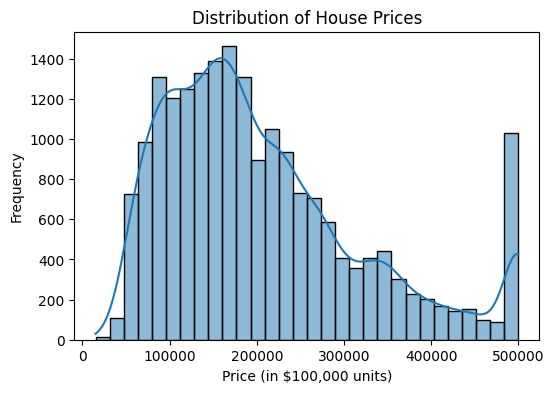

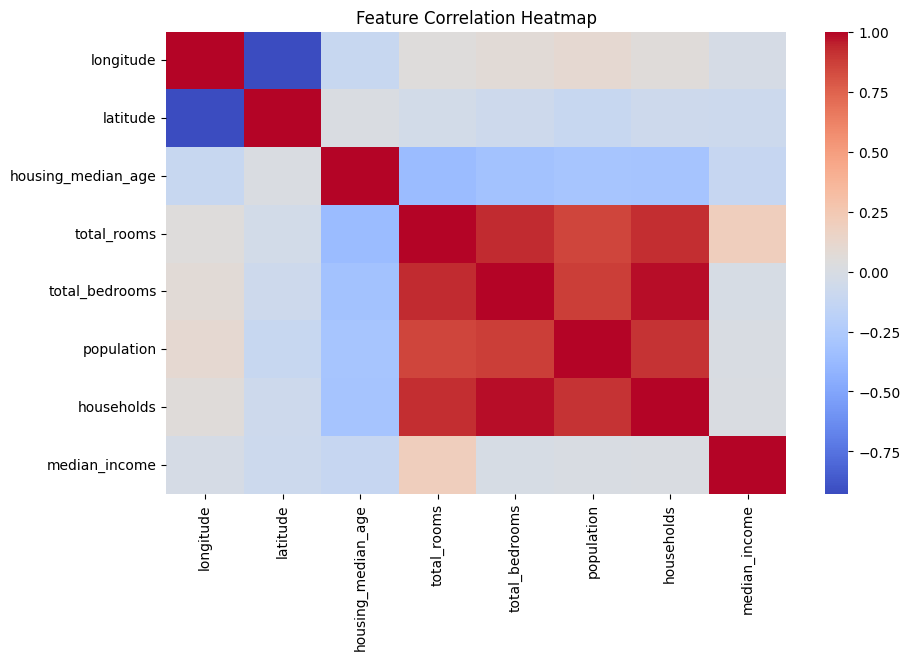

Mean Squared Error: 4869758532.5198
Mean Absolute Error: 50564.3587
Root Mean Squared Error: 69783.6552
R² Score: 0.6453


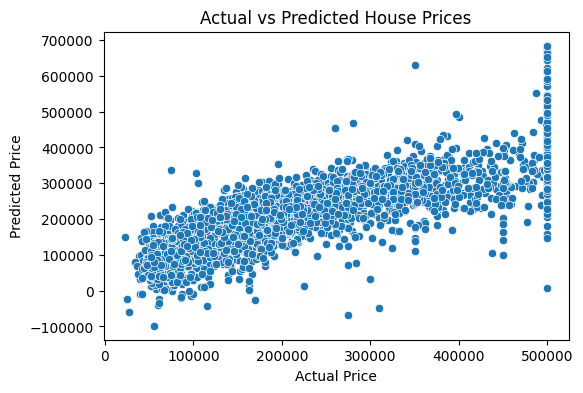

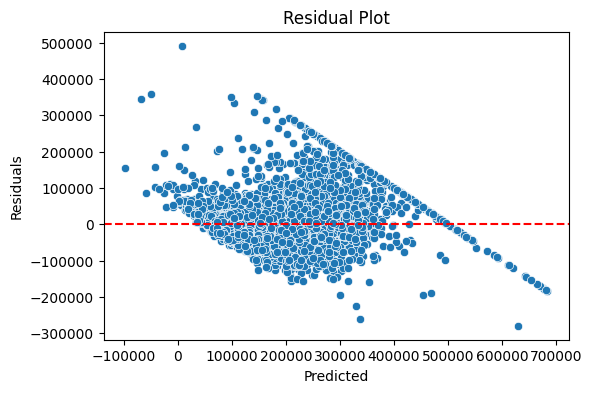

                     Coefficient
longitude          -86993.340648
latitude           -91297.782607
housing_median_age  14599.082730
total_rooms        -18675.948893
total_bedrooms      48271.168482
population         -41661.031760
households          16928.440067
median_income       76378.489533


<Figure size 800x400 with 0 Axes>

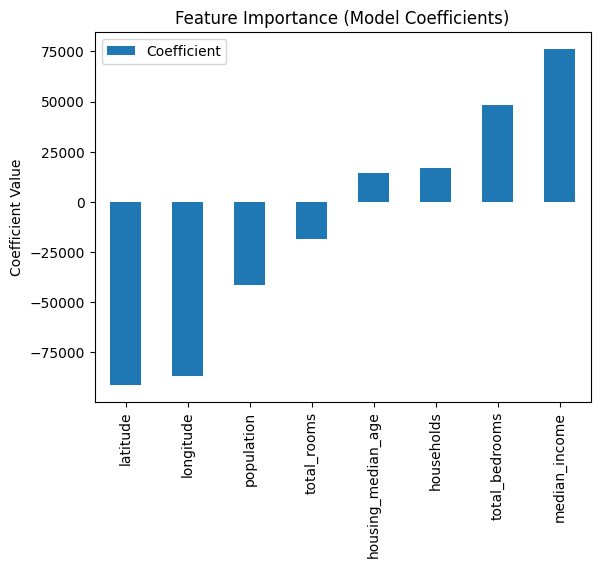

Model and scaler saved successfully.


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# from sklearn.datasets import fetch_california_housing # No longer needed if loading from CSV

# Load dataset from local CSV files
train_df = pd.read_csv('/content/sample_data/california_housing_train.csv')
test_df = pd.read_csv('/content/sample_data/california_housing_test.csv')

# Combine train and test data
housing_df = pd.concat([train_df, test_df], ignore_index=True)

# Assuming 'median_house_value' is the target column in the CSVs
y = housing_df['median_house_value']
X = housing_df.drop('median_house_value', axis=1)

print("Dataset loaded successfully from local CSVs. Shape:", X.shape)
print(X.head())

# ------------------------------
# 1. Distribution of Target Values
# ------------------------------
plt.figure(figsize=(6, 4))
sns.histplot(y, bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price (in $100,000 units)")
plt.ylabel("Frequency")
plt.show()

# ------------------------------
# 2. Correlation Heatmap
# ------------------------------
plt.figure(figsize=(10, 6))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# ------------------------------
# Train-test split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model training
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# ------------------------------
# Evaluation
# ------------------------------
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

# ------------------------------
# 3. Actual vs Predicted Plot
# ------------------------------
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=y_pred)
plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

# ------------------------------
# 4. Residual Error Plot
# ------------------------------
residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

# ------------------------------
# 5. Feature Importance (Coefficients)
# ------------------------------
coef = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print(coef)

plt.figure(figsize=(8, 4))
coef.sort_values(by="Coefficient").plot(kind="bar")
plt.title("Feature Importance (Model Coefficients)")
plt.ylabel("Coefficient Value")
plt.show()

# ------------------------------
# Save Model for Deployment
# ------------------------------
joblib.dump(model, "house_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Model and scaler saved successfully.")